<a href="https://colab.research.google.com/github/adwait-ops/GW-ODW-2025/blob/main/Challenge_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving challenge2.gwf to challenge2.gwf


In [3]:
!pip install -q lalsuite gwpy pycbc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 110.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently t

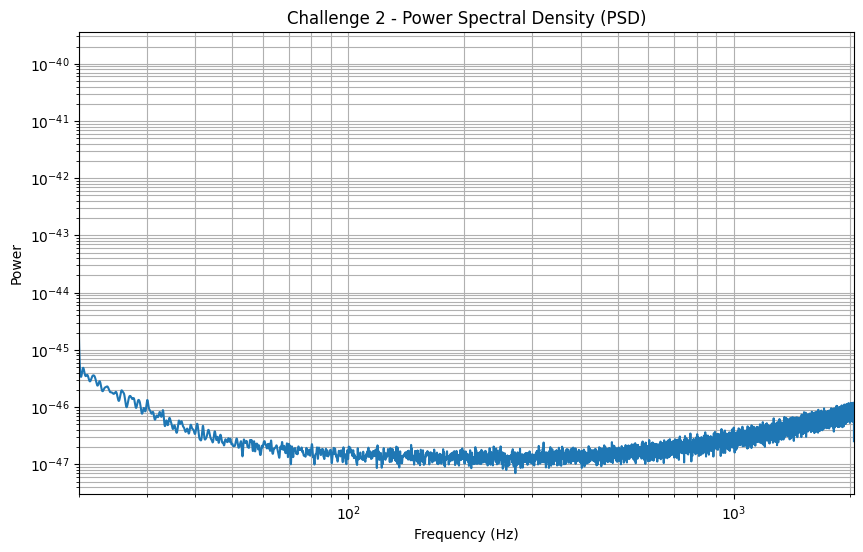

--- Challenge 2 Results ---
Approximate Merger Time: 48.5186 seconds
Matched Filter SNR: 22.09


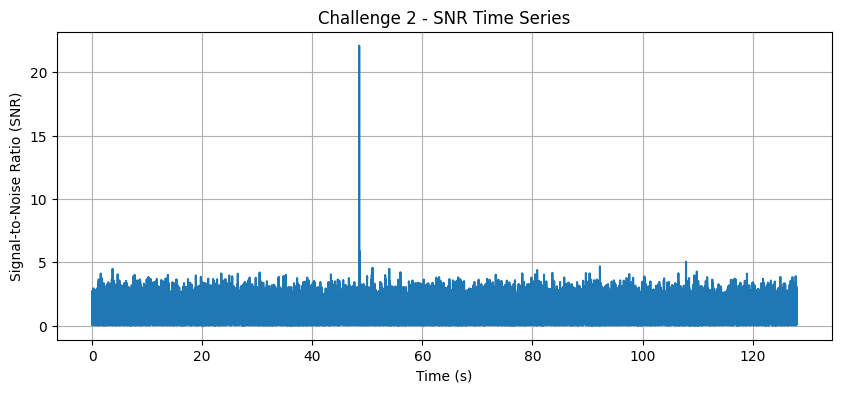

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from pycbc import frame
from pycbc.waveform import get_td_waveform
from pycbc.filter import matched_filter
from pycbc.psd import interpolate, inverse_spectrum_truncation

#load data
file_path = 'challenge2.gwf'
channel_name = "H1:CHALLENGE2"
strain = frame.read_frame(file_path, channel_name)

#calculate power spectral density (psd)
psd = strain.psd(4)
psd = interpolate(psd, strain.delta_f)
psd = inverse_spectrum_truncation(psd, int(4 * strain.sample_rate),
                                  low_frequency_cutoff=20)

#plot psd
plt.figure(figsize=(10, 6))
plt.loglog(psd.sample_frequencies, psd)
plt.title("Challenge 2 - Power Spectral Density (PSD)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.xlim(20, 2048)
plt.grid(True, which="both")
plt.show()

#generate tempelate waveform
hp, hc = get_td_waveform(approximant="SEOBNRv4_opt",
                         mass1=30,
                         mass2=30,
                         delta_t=strain.delta_t,
                         f_lower=20)
hp.resize(len(strain))

#calculate matched filter snr
snr = matched_filter(hp, strain, psd=psd, low_frequency_cutoff=20)

#find merger time and max snr
snr_segment = snr.crop(4, 4) #remove unwanted edges
snr_array = np.absolute(snr_segment.numpy())
peak_idx = snr_array.argmax()
peak_time = snr_segment.sample_times[peak_idx]
peak_snr = snr_array[peak_idx]

print(f"--- Challenge 2 Results ---")
print(f"Approximate Merger Time: {peak_time:.4f} seconds")
print(f"Matched Filter SNR: {peak_snr:.2f}")

#plot snr
plt.figure(figsize=(10, 4))
plt.plot(snr.sample_times, np.absolute(snr))
plt.ylabel('Signal-to-Noise Ratio (SNR)')
plt.xlabel('Time (s)')
plt.title('Challenge 2 - SNR Time Series')
plt.grid()
plt.show()